In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import tracemalloc
import gc

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
file_path = "smart_city_traffic_stress_dataset.csv"

data = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nFirst 5 Rows:")
display(data.head())

Dataset Shape:
(50000, 8)

Column Names:
['traffic_density', 'horn_events_per_min', 'avg_speed', 'signal_wait_time', 'weather_condition', 'road_quality_score', 'driver_experience_level', 'stress_index']

First 5 Rows:


,traffic_density,horn_events_per_min,avg_speed,signal_wait_time,weather_condition,road_quality_score,driver_experience_level,stress_index
0,112,12.93,28.61,56.58,Foggy,7.31,Intermediate,68.37
1,61,7.43,54.22,35.64,Rainy,8.78,Beginner,47.14
2,102,11.07,41.42,54.61,Clear,8.34,Intermediate,55.02
3,24,1.54,69.86,16.09,Clear,6.29,Expert,22.71
4,116,11.60,33.01,62.51,Clear,8.19,Expert,49.91


In [4]:
print("Missing Values in Each Column:")
display(data.isnull().sum())

Missing Values in Each Column:


traffic_density            0
horn_events_per_min        0
avg_speed                  0
signal_wait_time           0
weather_condition          0
road_quality_score         0
driver_experience_level    0
stress_index               0
dtype: int64

In [5]:
target = "stress_index"

X = data.drop(columns=[target])
y = data[target]

print("Input variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print(target)

Input variables:
['traffic_density', 'horn_events_per_min', 'avg_speed', 'signal_wait_time', 'weather_condition', 'road_quality_score', 'driver_experience_level']

Target variable:
stress_index


In [6]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['traffic_density', 'horn_events_per_min', 'avg_speed', 'signal_wait_time', 'road_quality_score']

Categorical Features:
['weather_condition', 'driver_experience_level']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 40000
Testing samples : 10000


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),

        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),

        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [10]:
mlr_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

print("MLR model created.")

MLR model created.


In [11]:
knnr_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsRegressor(
        n_neighbors=5,
        weights="uniform",
        n_jobs=-1
    ))
])

print("KNNR model created with K = 5.")

KNNR model created with K = 5.


In [12]:
gc.collect()

tracemalloc.start()

start_time = time.perf_counter()

mlr_model.fit(X_train, y_train)

mlr_predictions = mlr_model.predict(X_test)

mlr_time = time.perf_counter() - start_time

current_memory, mlr_peak_memory = tracemalloc.get_traced_memory()

tracemalloc.stop()

mlr_peak_memory_mb = mlr_peak_memory / (1024 * 1024)

mlr_r2 = r2_score(y_test, mlr_predictions)

mlr_rmse = np.sqrt(
    mean_squared_error(y_test, mlr_predictions)
)

mlr_mae = mean_absolute_error(
    y_test,
    mlr_predictions
)

print("========== MULTIPLE LINEAR REGRESSION ==========")
print("R² Score       :", round(mlr_r2, 4))
print("RMSE           :", round(mlr_rmse, 4))
print("MAE            :", round(mlr_mae, 4))
print("Execution Time :", round(mlr_time, 4), "seconds")
print("Peak Memory    :", round(mlr_peak_memory_mb, 4), "MB")

========== MULTIPLE LINEAR REGRESSION ==========
R² Score       : 0.8968
RMSE           : 5.218
MAE            : 4.1698
Execution Time : 2.2809 seconds
Peak Memory    : 12.2415 MB


In [13]:
gc.collect()

tracemalloc.start()

start_time = time.perf_counter()

knnr_model.fit(X_train, y_train)

knnr_predictions = knnr_model.predict(X_test)

knnr_time = time.perf_counter() - start_time

current_memory, knnr_peak_memory = tracemalloc.get_traced_memory()

tracemalloc.stop()

knnr_peak_memory_mb = knnr_peak_memory / (1024 * 1024)

knnr_r2 = r2_score(y_test, knnr_predictions)

knnr_rmse = np.sqrt(
    mean_squared_error(y_test, knnr_predictions)
)

knnr_mae = mean_absolute_error(
    y_test,
    knnr_predictions
)

print("========== K-NEAREST NEIGHBORS REGRESSION ==========")
print("R² Score       :", round(knnr_r2, 4))
print("RMSE           :", round(knnr_rmse, 4))
print("MAE            :", round(knnr_mae, 4))
print("Execution Time :", round(knnr_time, 4), "seconds")
print("Peak Memory    :", round(knnr_peak_memory_mb, 4), "MB")

========== K-NEAREST NEIGHBORS REGRESSION ==========
R² Score       : 0.8914
RMSE           : 5.3539
MAE            : 4.2773
Execution Time : 3.2073 seconds
Peak Memory    : 11.228 MB


In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "K-Nearest Neighbors Regression"
    ],

    "R2 Score": [
        mlr_r2,
        knnr_r2
    ],

    "RMSE": [
        mlr_rmse,
        knnr_rmse
    ],

    "MAE": [
        mlr_mae,
        knnr_mae
    ],

    "Execution Time (s)": [
        mlr_time,
        knnr_time
    ],

    "Peak Memory (MB)": [
        mlr_peak_memory_mb,
        knnr_peak_memory_mb
    ]
})

display(comparison.round(4))

,Model,R2 Score,RMSE,MAE,Execution Time (s),Peak Memory (MB)
0,Multiple Linear Regression,0.8968,5.2180,4.1698,2.2809,12.2415
1,K-Nearest Neighbors Regression,0.8914,5.3539,4.2773,3.2073,11.2280


In [15]:
comparison.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


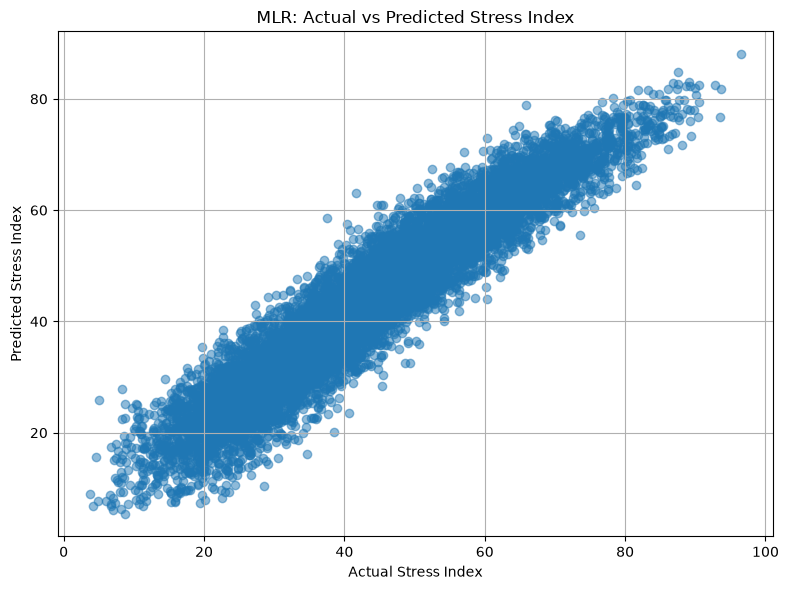

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    mlr_predictions,
    alpha=0.5
)

plt.xlabel("Actual Stress Index")
plt.ylabel("Predicted Stress Index")
plt.title("MLR: Actual vs Predicted Stress Index")

plt.grid(True)
plt.tight_layout()

plt.show()

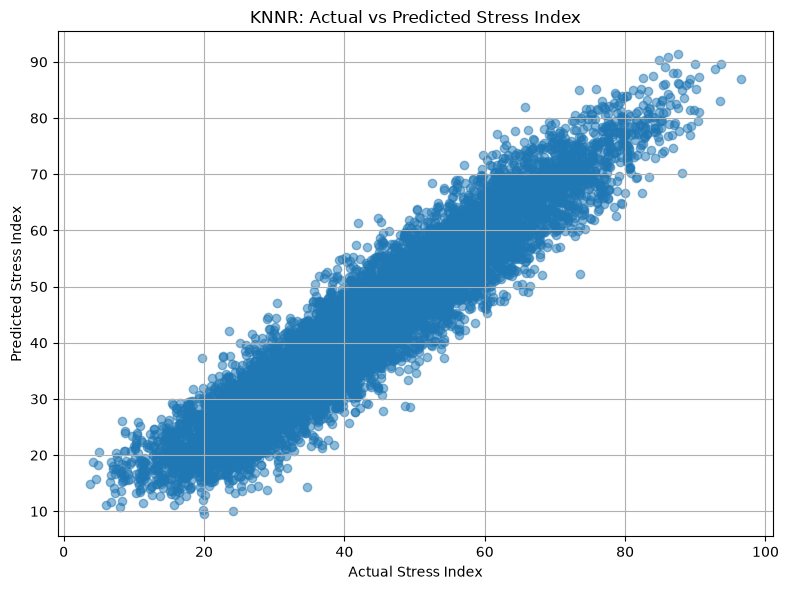

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    knnr_predictions,
    alpha=0.5
)

plt.xlabel("Actual Stress Index")
plt.ylabel("Predicted Stress Index")
plt.title("KNNR: Actual vs Predicted Stress Index")

plt.grid(True)
plt.tight_layout()

plt.show()

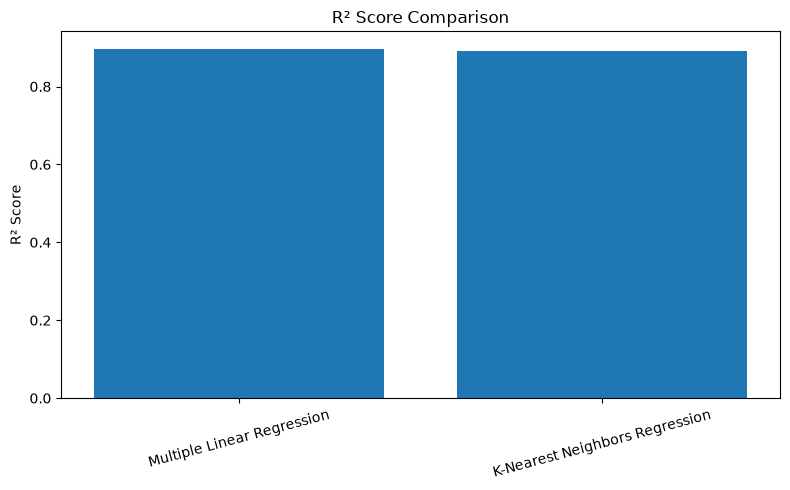

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

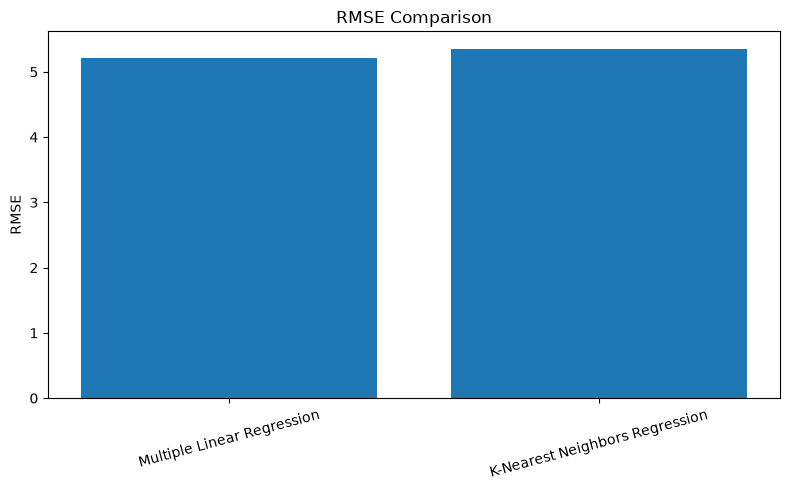

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

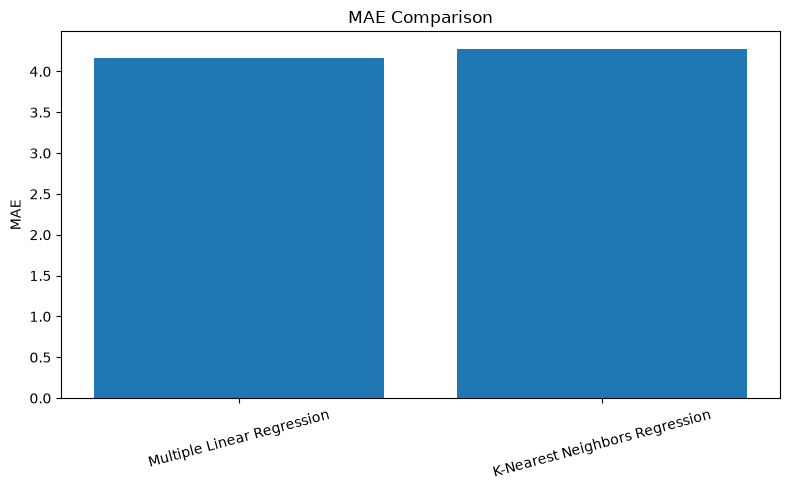

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.ylabel("MAE")
plt.title("MAE Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

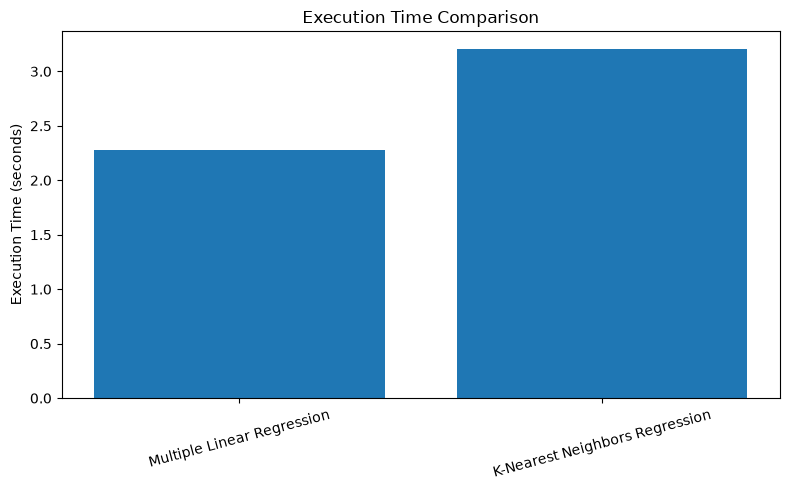

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Execution Time (s)"]
)

plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

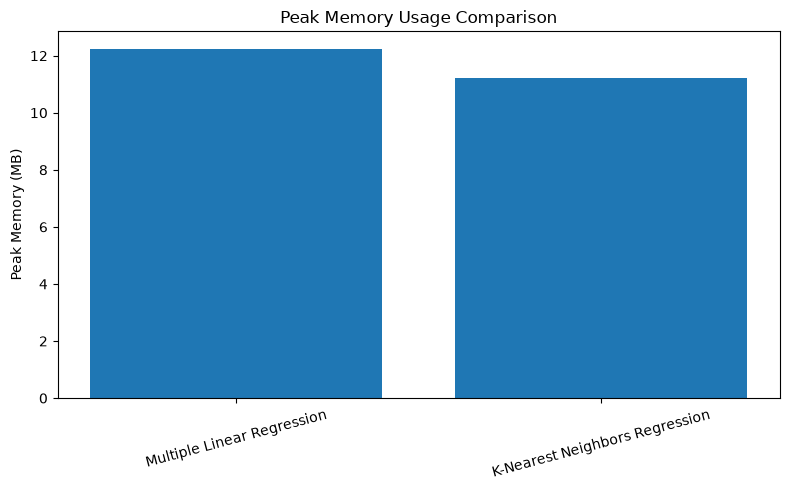

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Peak Memory (MB)"]
)

plt.ylabel("Peak Memory (MB)")
plt.title("Peak Memory Usage Comparison")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

In [23]:
print("==============================================")
print("FINAL CONCLUSION")
print("==============================================")

if mlr_r2 > knnr_r2:
    print("MLR has the higher R² score.")
else:
    print("KNNR has the higher R² score.")

if mlr_rmse < knnr_rmse:
    print("MLR has the lower RMSE.")
else:
    print("KNNR has the lower RMSE.")

if mlr_mae < knnr_mae:
    print("MLR has the lower MAE.")
else:
    print("KNNR has the lower MAE.")

if mlr_time < knnr_time:
    print("MLR has the lower execution time.")
else:
    print("KNNR has the lower execution time.")

FINAL CONCLUSION
MLR has the higher R² score.
MLR has the lower RMSE.
MLR has the lower MAE.
MLR has the lower execution time.
